In [8]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
def pixel_logical_op(a, b=None, op='NOT'):  # AND, OR require 2 images / NOT requires only 1
    ops = {
        'AND': lambda x, y: x & y,
        'OR' : lambda x, y: x | y,
        'NOT': lambda x, _: 1 - x,  # binary (0 or 1)
    }
    return int(ops[op](a, b))


def img_logical_op(arr_a, arr_b=None, op='NOT'):
    if op in ('AND', 'OR'):
        if arr_b is None:
            return None
        if arr_a.shape != arr_b.shape: # check shape
            return None

    a = arr_a.astype(int)
    b = arr_b.astype(int) if arr_b is not None else np.zeros_like(a)
    result = np.zeros_like(a, dtype=int)

    for idx in np.ndindex(a.shape):
        result[idx] = pixel_logical_op(a[idx], b[idx], op)

    return result.astype(np.uint8)

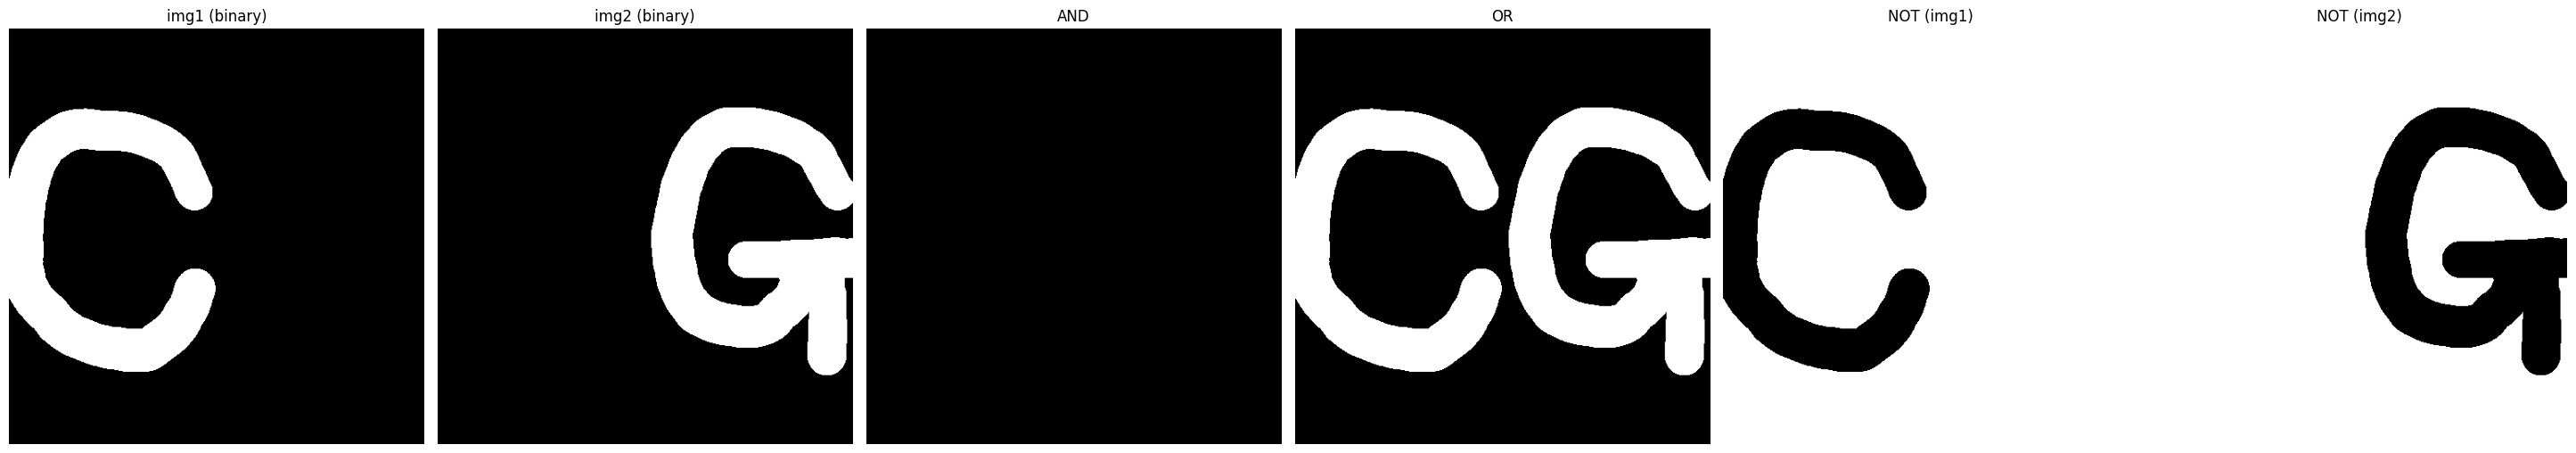

In [ ]:
img1 = np.array(Image.open("image\\c.png").convert("L"))
img2 = np.array(Image.open("image\\g.png").convert("L"))

# convert binary image
img1_bin = (img1 / 255).astype(np.uint8)
img2_bin = (img2 / 255).astype(np.uint8)

and_result = img_logical_op(img1_bin, img2_bin, op='AND')
or_result  = img_logical_op(img1_bin, img2_bin, op='OR')
not_result1 = img_logical_op(img1_bin, op='NOT')
not_result2 = img_logical_op(img2_bin, op='NOT')

fig, axes = plt.subplots(1, 6, figsize=(29, 9))
axes[0].imshow(img1_bin, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('img1 (binary)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(img2_bin, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('img2 (binary)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(and_result, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('AND', fontsize=12)
axes[2].axis('off')

axes[3].imshow(or_result, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('OR', fontsize=12)
axes[3].axis('off')

axes[4].imshow(not_result1, cmap='gray', vmin=0, vmax=1)
axes[4].set_title('NOT (img1)', fontsize=12)
axes[4].axis('off')

axes[5].imshow(not_result2, cmap='gray', vmin=0, vmax=1)
axes[5].set_title('NOT (img2)', fontsize=12)
axes[5].axis('off')

plt.tight_layout()
plt.show()